Task3. Data Exploration

In [10]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:/Users/ASUS/OneDrive/Desktop/Uni/5 term/Pattern ML/task 3/MLPC2026_dataset_development")

ANNOTATIONS_CSV = PROJECT_ROOT / "annotations.csv"
METADATA_CSV = PROJECT_ROOT / "metadata.csv"
AUDIO_FEATURES_DIR = PROJECT_ROOT / "audio_features"

assert ANNOTATIONS_CSV.exists(), f"Missing: {ANNOTATIONS_CSV}"
assert METADATA_CSV.exists(), f"Missing: {METADATA_CSV}"
assert AUDIO_FEATURES_DIR.exists(), f"Missing: {AUDIO_FEATURES_DIR}"

print("Annotations:", ANNOTATIONS_CSV)
print("Metadata   :", METADATA_CSV)
print("Features   :", AUDIO_FEATURES_DIR)

Annotations: C:\Users\ASUS\OneDrive\Desktop\Uni\5 term\Pattern ML\task 3\MLPC2026_dataset_development\annotations.csv
Metadata   : C:\Users\ASUS\OneDrive\Desktop\Uni\5 term\Pattern ML\task 3\MLPC2026_dataset_development\metadata.csv
Features   : C:\Users\ASUS\OneDrive\Desktop\Uni\5 term\Pattern ML\task 3\MLPC2026_dataset_development\audio_features


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from itertools import combinations
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 1. Load metadata and CSV annotations

In [12]:
ann_csv = pd.read_csv(ANNOTATIONS_CSV)
meta = pd.read_csv(METADATA_CSV)

print("annotations.csv shape:", ann_csv.shape)
print("metadata.csv shape   :", meta.shape)
display(ann_csv.head())
display(meta.head())

annotations.csv shape: (37419, 6)
metadata.csv shape   : (3656, 9)


,filename,annotator_id,annotation,onset,offset,is_own_recording
0,000112.wav,2190518039615423109192646528977018723001939610...,footsteps,13.060211,13.315831,False
1,000695.wav,4496809211053681637690999252976315563042618669...,door_open_close,1.508440,2.061877,False
2,000488.wav,7535443191697509271271535104115945129183028445...,microwave,4.833705,25.929958,True
3,005087.wav,4496809211053681637690999252976315563042618669...,keyboard_typing,0.337356,18.230374,False
4,005465.wav,7618427328765435143030208879017391647684958822...,running_water,5.254437,15.088430,True


,filename,target_classes,recording_device,device_placement,recording_environment,scene_description,license,collector_id,non_target_classes
0,003075.wav,keyboard_typing;keychain,IPhone Xr,static,office,I was working on my laptop and playing with ke...,CC0 (Public Domain Dedication),04d6c4738cd1814c,fan_working;hand_moving_on_table
1,001117.wav,footsteps,Iphone 15 Pro,mobile,office,"I was walking and recorded a bird singing, car...",CC0 (Public Domain Dedication),f125c6e647565367,bird_sing;car
2,001982.wav,footsteps;door_open_close;cutlery_dishes,Surface Pro 8,static,living_room,I went to the patio door and opened it. I went...,CC0 (Public Domain Dedication),23f33a22e31d3072,NaN
3,003018.wav,footsteps;toilet_flushing;running_water,IPhone 15 Pro Max,static,bathroom,I flushed the toilet and walked to the sink. I...,CC0 (Public Domain Dedication),0ada14bcb30cabc5,towel_rustling;coughing;toilet_tank_refilling
4,002291.wav,light_switch;footsteps,Iphone 15 pro,mobile,bedroom;kitchen;bathroom,I turn on light switches around rooms while wa...,CC0 (Public Domain Dedication),9141efc68a18c882,NaN


In [13]:
print("Annotation columns:", ann_csv.columns.tolist())
print("Metadata columns  :", meta.columns.tolist())
print("\nUnique target classes from annotations.csv:")
print(sorted(ann_csv["annotation"].dropna().unique().tolist()))

Annotation columns: ['filename', 'annotator_id', 'annotation', 'onset', 'offset', 'is_own_recording']
Metadata columns  : ['filename', 'target_classes', 'recording_device', 'device_placement', 'recording_environment', 'scene_description', 'license', 'collector_id', 'non_target_classes']

Unique target classes from annotations.csv:
['bell_ringing', 'coffee_machine', 'cutlery_dishes', 'door_open_close', 'footsteps', 'keyboard_typing', 'keychain', 'light_switch', 'microwave', 'phone_ringing', 'running_water', 'toilet_flushing', 'vacuum_cleaner', 'wardrobe_drawer_open_close', 'window_open_close']


## 2. Inspect one `.npz` file and dataset keys

In [14]:
feature_files = sorted(AUDIO_FEATURES_DIR.glob("*.npz"))
print("Number of .npz files:", len(feature_files))
assert len(feature_files) > 0, "No .npz files found."

def safe_npz_load(npz_path):
    try:
        return dict(np.load(npz_path, allow_pickle=True))
    except Exception as e:
        print(f"FAILED to load {npz_path.name}: {e}")
        return None

sample = None
for path in feature_files:
    sample = safe_npz_load(path)
    if sample is not None:
        print("Sample file:", path.name)
        for key in sample.keys():
            arr = np.asarray(sample[key])
            print(f"{key:24s} shape={arr.shape} dtype={arr.dtype}")
        break

assert sample is not None, "Could not load any .npz file."

Number of .npz files: 3656
Sample file: 000001.npz
zcr_mean                 shape=(61, 1) dtype=float64
zcr_std                  shape=(61, 1) dtype=float64
zcr_min                  shape=(61, 1) dtype=float64
zcr_max                  shape=(61, 1) dtype=float64
start_time               shape=(61,) dtype=float64
end_time                 shape=(61,) dtype=float64
melspect_mean            shape=(61, 128) dtype=float32
melspect_std             shape=(61, 128) dtype=float32
melspect_min             shape=(61, 128) dtype=float32
melspect_max             shape=(61, 128) dtype=float32
mfcc_mean                shape=(61, 32) dtype=float32
mfcc_std                 shape=(61, 32) dtype=float32
mfcc_min                 shape=(61, 32) dtype=float32
mfcc_max                 shape=(61, 32) dtype=float32
mfcc_d_mean              shape=(61, 32) dtype=float32
mfcc_d_std               shape=(61, 32) dtype=float32
mfcc_d_min               shape=(61, 32) dtype=float32
mfcc_d_max               shape=(61, 3

## 3. Parameters and helper functions

### Label aggregation strategy (important for the report)
We derive **binary labels for every segment** from `annotations[T, C, A]` in two steps:

1. **Per annotator binarization**  
   A segment is positive for one annotator if the overlap value is **greater than 0**.

2. **Aggregation across annotators**  
   We compute the fraction of annotators that marked the segment as positive for that class.  
   The final binary target is **1** if that support is at least `0.5`, otherwise `0`.

### Assumptions behind this binarization
- any overlap in a 1-second segment counts as evidence that the class is present in that segment
- all annotators are treated as equally reliable
- a majority vote is a reasonable way to obtain a single target per segment

### Possible imperfections
- very short events at segment boundaries may become positive even if the overlap is tiny
- slight onset/offset differences can create disagreement near boundaries
- in difficult files, a majority vote can still be wrong if most annotators made the same mistake

In [15]:
PER_ANNOTATOR_OVERLAP_THRESHOLD = 0.0   # any overlap counts as positive for one annotator
MAJORITY_THRESHOLD = 0.5                # majority vote across annotators
HIGH_AGREEMENT_THRESHOLD = 0.75         # for the PCA visualization subset
MAX_SEGMENTS_PER_CLASS_FOR_PCA = 250    # keeps the notebook fast enough

FEATURE_BASES = [
    "zcr", "melspect", "mfcc", "mfcc_d", "mfcc_d2",
    "flux", "flatness", "centroid", "bandwidth", "contrast",
    "rolloff_low", "rolloff_high", "energy", "power"
]
FEATURE_SUFFIXES = ["mean", "std", "min", "max"]
EXPECTED_FEATURE_KEYS = [f"{base}_{suffix}" for base in FEATURE_BASES for suffix in FEATURE_SUFFIXES]

VIZ_FEATURE_KEYS = [
    "melspect_mean",
    "mfcc_mean", "mfcc_std", "mfcc_d_mean", "mfcc_d2_mean",
    "contrast_mean",
    "centroid_mean", "bandwidth_mean",
    "rolloff_low_mean", "rolloff_high_mean",
    "flatness_mean", "flux_mean", "zcr_mean",
    "energy_mean", "power_mean"
]

META_LOOKUP = meta.set_index("filename").to_dict(orient="index")

In [16]:
def parse_semicolon_list(value):
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            value = value.item()
        else:
            value = ";".join(map(str, value.tolist()))
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "-", "[]"}:
        return []
    return [x.strip() for x in text.split(";") if x.strip() and x.strip() not in {"-", "None", "nan"}]

def get_target_classes_from_any_source(npz_data, filename):
    if "target_classes" in npz_data:
        return set(parse_semicolon_list(npz_data["target_classes"]))
    row = META_LOOKUP.get(filename, {})
    return set(parse_semicolon_list(row.get("target_classes", None)))

def get_recording_environments_from_any_source(npz_data, filename):
    if "recording_environments" in npz_data:
        return parse_semicolon_list(npz_data["recording_environments"])
    row = META_LOOKUP.get(filename, {})
    return parse_semicolon_list(row.get("recording_environment", None))

def get_device_placement_from_any_source(npz_data, filename):
    if "device_placement" in npz_data:
        arr = np.asarray(npz_data["device_placement"])
        if arr.ndim == 0:
            return str(arr.item())
        return str(arr.tolist()[0])
    row = META_LOOKUP.get(filename, {})
    return str(row.get("device_placement", "unknown"))

def to_python_strings(arr):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return [str(arr.item())]
    return [str(x) for x in arr.tolist()]

def binarize_per_annotator(ann_soft):
    return (ann_soft > PER_ANNOTATOR_OVERLAP_THRESHOLD).astype(np.uint8)

def aggregate_to_segment_labels(ann_soft):
    ann_bin = binarize_per_annotator(ann_soft)          # [T, C, A]
    support = ann_bin.mean(axis=2)                      # [T, C]
    derived = (support >= MAJORITY_THRESHOLD).astype(np.uint8)
    return ann_bin, support, derived

def pairwise_jaccard_scores(binary_matrix_tc_by_a):
    # input: [T, A] for a single class
    A = binary_matrix_tc_by_a.shape[1]
    scores = []
    if A < 2:
        return scores
    for a1, a2 in combinations(range(A), 2):
        x = binary_matrix_tc_by_a[:, a1].astype(bool)
        y = binary_matrix_tc_by_a[:, a2].astype(bool)
        union = np.logical_or(x, y).sum()
        if union == 0:
            continue
        inter = np.logical_and(x, y).sum()
        scores.append(inter / union)
    return scores

def positive_runs(mask):
    # Important: use a signed integer dtype before np.diff.
    # With uint8, a transition 1 -> 0 would wrap to 255 instead of -1,
    # which would hide segment endings and break duration extraction.
    mask = np.asarray(mask).astype(np.int8)
    padded = np.pad(mask, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded.astype(np.int8))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return starts, ends

def empty_df(columns):
    return pd.DataFrame(columns=columns)

def safe_numeric_array(npz_data, key):
    if key not in npz_data:
        return None
    arr = np.asarray(npz_data[key])
    if not np.issubdtype(arr.dtype, np.number):
        return None
    if arr.size == 0:
        return None
    arr = arr.astype(np.float32)
    if not np.isfinite(arr).all():
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

def summarize_feature_row(arr, t_index):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 1:
        if t_index >= arr.shape[0]:
            return None
        return np.array([arr[t_index]], dtype=np.float32)
    if arr.ndim >= 2:
        if t_index >= arr.shape[0]:
            return None
        return arr[t_index].reshape(-1).astype(np.float32)
    return None

## 4. Quick metadata overview (required by rubric 3a)

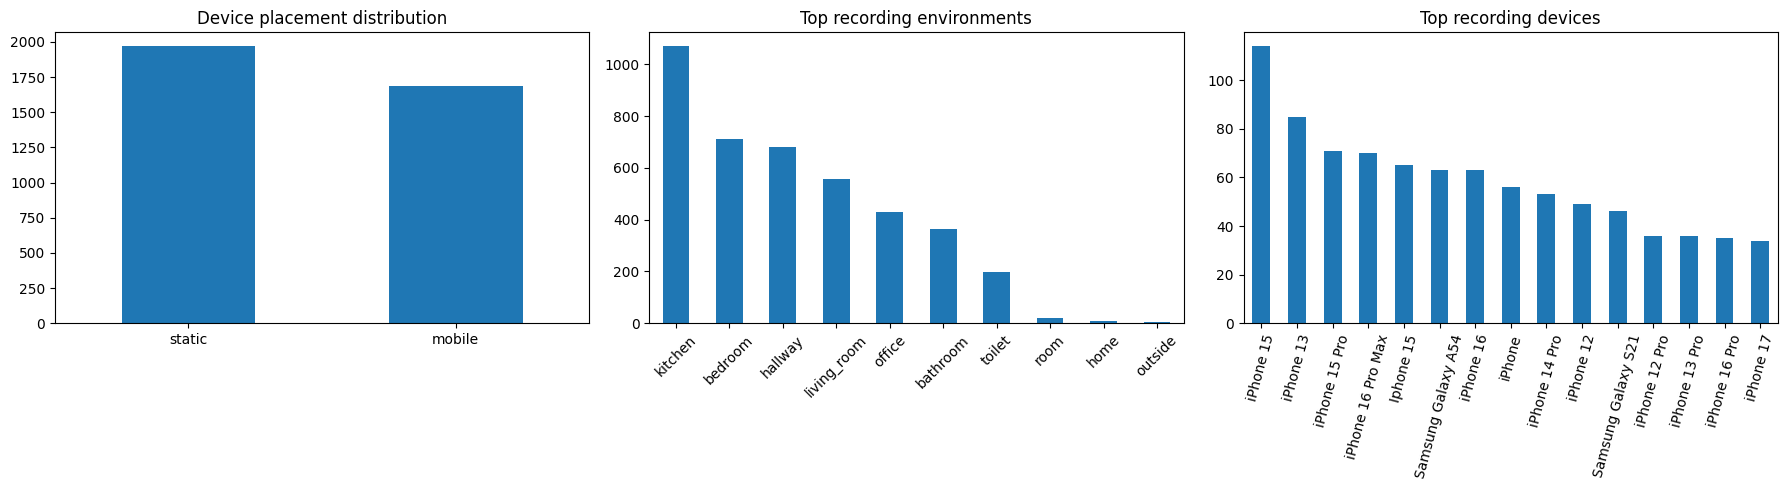

,device_placement_count
device_placement,
static,1970
mobile,1686


,count
recording_environment,
kitchen,1070
bedroom,711
hallway,682
living_room,557
office,430
bathroom,364
toilet,199
room,20
home,8


In [17]:
meta_plot = meta.copy()

placement_counts = meta_plot["device_placement"].fillna("unknown").value_counts()
env_counts = (
    meta_plot["recording_environment"]
    .fillna("")
    .apply(parse_semicolon_list)
    .explode()
    .replace("", np.nan)
    .dropna()
    .value_counts()
)
device_counts = meta_plot["recording_device"].fillna("unknown").value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

placement_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Device placement distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

env_counts.head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top recording environments")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

device_counts.plot(kind="bar", ax=axes[2])
axes[2].set_title("Top recording devices")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "device_placement_count": placement_counts
}).fillna(0).astype(int))

display(env_counts.head(15).to_frame("count"))

## 5. Main loop over `.npz` files

This loop does all rubric-critical work:
- segment-level annotator agreement
- segment-level label derivation
- label characteristics
- metadata vs temporal-label agreement
- feature statistics
- feature-family correlation summaries
- a high-quality subset for PCA down-projection

In [18]:
# --- accumulators ---
failed_files = []
class_names_reference = None

overall_pairwise_scores = []
pairwise_scores_by_class = defaultdict(list)

metadata_vs_temporal_exact_match = []
metadata_vs_temporal_class_records = []

positive_segment_counts = Counter()
file_presence_counts = Counter()
segment_event_durations = defaultdict(list)
cooccurrence_counts = Counter()

environment_counts = Counter()
environment_class_presence = defaultdict(Counter)

feature_stats = {
    key: {"count": 0, "sum": 0.0, "sumsq": 0.0, "min": np.inf, "max": -np.inf}
    for key in EXPECTED_FEATURE_KEYS
}

feature_family_rows = []

viz_features = []
viz_labels = []
viz_environments = []
viz_supports = []
viz_counts_per_class = Counter()

num_processed = 0

for i, npz_path in enumerate(feature_files, start=1):
    npz_data = safe_npz_load(npz_path)
    if npz_data is None:
        failed_files.append((npz_path.name, "load_failed"))
        continue

    filename = npz_path.with_suffix(".wav").name

    # --- annotations ---
    if "annotations" not in npz_data or "class_names" not in npz_data:
        failed_files.append((npz_path.name, "missing_annotations_or_class_names"))
        continue

    ann_soft = np.asarray(npz_data["annotations"], dtype=np.float32)   # [T, C, A]
    class_names = to_python_strings(npz_data["class_names"])

    if ann_soft.ndim != 3:
        failed_files.append((npz_path.name, f"bad_annotation_shape_{ann_soft.shape}"))
        continue

    if class_names_reference is None:
        class_names_reference = class_names

    ann_bin, support, derived = aggregate_to_segment_labels(ann_soft)

    T, C, A = ann_bin.shape

    # --- agreement ---
    for c_idx, c_name in enumerate(class_names):
        scores = pairwise_jaccard_scores(ann_bin[:, c_idx, :])
        if len(scores) > 0:
            pairwise_scores_by_class[c_name].extend(scores)
            overall_pairwise_scores.extend(scores)

    # --- metadata tags vs derived temporal labels ---
    derived_file_set = {class_names[c] for c in np.where(derived.any(axis=0))[0]}
    metadata_file_set = get_target_classes_from_any_source(npz_data, filename)

    metadata_vs_temporal_exact_match.append(derived_file_set == metadata_file_set)

    for c_name in class_names:
        metadata_vs_temporal_class_records.append({
            "filename": filename,
            "class_name": c_name,
            "metadata_tag": int(c_name in metadata_file_set),
            "temporal_label": int(c_name in derived_file_set),
        })

    # --- label characteristics ---
    start_time = safe_numeric_array(npz_data, "start_time")
    end_time = safe_numeric_array(npz_data, "end_time")

    file_presence = derived.any(axis=0)

    for c_idx, c_name in enumerate(class_names):
        positive_segment_counts[c_name] += int(derived[:, c_idx].sum())
        if file_presence[c_idx]:
            file_presence_counts[c_name] += 1

        if start_time is not None and end_time is not None:
            starts, ends = positive_runs(derived[:, c_idx])
            for s, e in zip(starts, ends):
                duration = float(end_time[e] - start_time[s])
                if duration > 0:
                    segment_event_durations[c_name].append(duration)

    positive_classes = [class_names[c] for c in np.where(file_presence)[0]]
    for c1, c2 in combinations(sorted(positive_classes), 2):
        cooccurrence_counts[(c1, c2)] += 1

    envs = get_recording_environments_from_any_source(npz_data, filename)
    for env in envs:
        environment_counts[env] += 1
        for c_name in positive_classes:
            environment_class_presence[env][c_name] += 1

    # --- feature statistics over all numeric values ---
    for key in EXPECTED_FEATURE_KEYS:
        arr = safe_numeric_array(npz_data, key)
        if arr is None:
            continue
        flat = arr.reshape(-1).astype(np.float64)
        if flat.size == 0:
            continue
        stat = feature_stats[key]
        stat["count"] += flat.size
        stat["sum"] += float(flat.sum())
        stat["sumsq"] += float(np.square(flat).sum())
        stat["min"] = min(stat["min"], float(flat.min()))
        stat["max"] = max(stat["max"], float(flat.max()))

    # --- feature-family rows for correlation (file-level summaries) ---
    row = {"filename": filename}
    for base in FEATURE_BASES:
        values = []
        for suffix in FEATURE_SUFFIXES:
            arr = safe_numeric_array(npz_data, f"{base}_{suffix}")
            if arr is None:
                continue
            values.append(float(np.mean(np.abs(arr))))
        row[base] = np.mean(values) if len(values) > 0 else np.nan
    feature_family_rows.append(row)

    # --- high-quality single-class segments for PCA ---
    single_class_mask = (derived.sum(axis=1) == 1)
    segment_support = support.max(axis=1)
    quality_mask = single_class_mask & (segment_support >= HIGH_AGREEMENT_THRESHOLD)

    selected_indices = np.where(quality_mask)[0]
    for t in selected_indices:
        class_idx = int(np.where(derived[t] == 1)[0][0])
        class_name = class_names[class_idx]

        if viz_counts_per_class[class_name] >= MAX_SEGMENTS_PER_CLASS_FOR_PCA:
            continue

        parts = []
        ok = True
        for key in VIZ_FEATURE_KEYS:
            arr = safe_numeric_array(npz_data, key)
            if arr is None:
                ok = False
                break
            row_vec = summarize_feature_row(arr, t)
            if row_vec is None:
                ok = False
                break
            parts.append(row_vec)

        if ok:
            viz_features.append(np.concatenate(parts))
            viz_labels.append(class_name)
            viz_environments.append(envs[0] if len(envs) > 0 else "unknown")
            viz_supports.append(float(segment_support[t]))
            viz_counts_per_class[class_name] += 1

    num_processed += 1
    if i % 500 == 0:
        print(f"Processed {i}/{len(feature_files)} files...")

print("Processed files:", num_processed)
print("Failed files   :", len(failed_files))
if len(failed_files) > 0:
    display(pd.DataFrame(failed_files, columns=["file", "reason"]).head(20))

Processed 500/3656 files...
Processed 1000/3656 files...
Processed 1500/3656 files...
Processed 2000/3656 files...
Processed 2500/3656 files...
Processed 3000/3656 files...
Processed 3500/3656 files...
Processed files: 3656
Failed files   : 0


## 6. Annotator agreement (required by rubric 2a)

Overall mean pairwise segment-level Jaccard agreement: 0.7004


,class_name,mean_pairwise_jaccard,median_pairwise_jaccard,num_pair_scores
12,vacuum_cleaner,0.874387,0.973329,530
0,keyboard_typing,0.851341,0.933333,1178
8,running_water,0.837203,0.947368,1579
1,phone_ringing,0.797789,0.909091,1237
14,coffee_machine,0.789730,0.935133,316
10,microwave,0.782008,0.925463,628
9,toilet_flushing,0.755715,0.857143,667
13,bell_ringing,0.752675,0.857143,430
4,keychain,0.719496,0.800000,1081
7,cutlery_dishes,0.690479,0.798148,1314


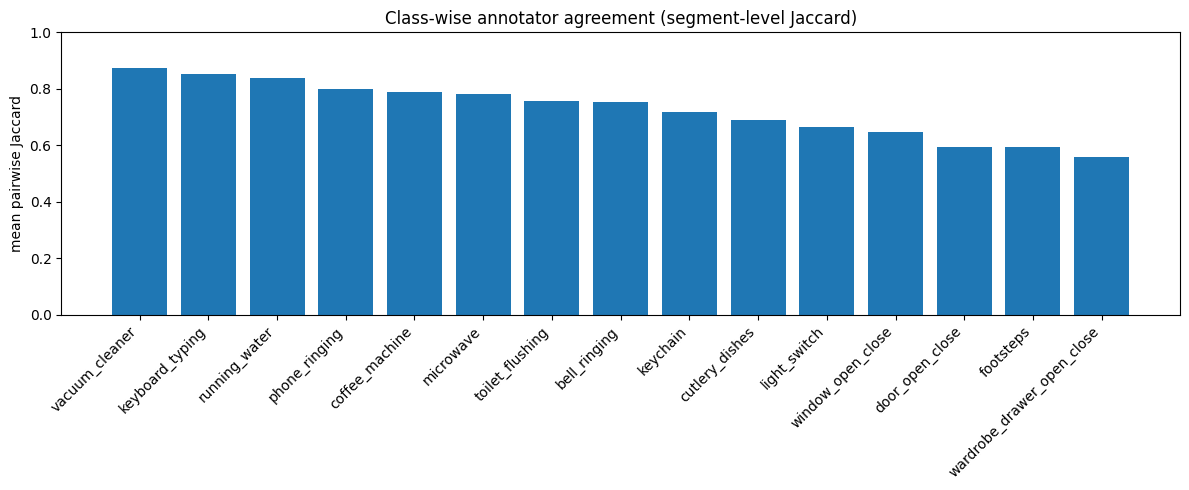

In [19]:
overall_agreement = float(np.mean(overall_pairwise_scores)) if len(overall_pairwise_scores) > 0 else np.nan
print("Overall mean pairwise segment-level Jaccard agreement:", round(overall_agreement, 4))

agreement_by_class_df = pd.DataFrame([
    {
        "class_name": c_name,
        "mean_pairwise_jaccard": float(np.mean(scores)),
        "median_pairwise_jaccard": float(np.median(scores)),
        "num_pair_scores": len(scores),
    }
    for c_name, scores in pairwise_scores_by_class.items()
    if len(scores) > 0
]).sort_values("mean_pairwise_jaccard", ascending=False)

display(agreement_by_class_df)

plt.figure(figsize=(12, 5))
plt.bar(agreement_by_class_df["class_name"], agreement_by_class_df["mean_pairwise_jaccard"])
plt.title("Class-wise annotator agreement (segment-level Jaccard)")
plt.ylabel("mean pairwise Jaccard")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Agreement between temporal labels and uploader target tags (required by rubric 2a)

Exact file-level set match between uploader tags and derived temporal labels: 0.8236


,class_name,match_rate,jaccard_positive_sets,metadata_positive_files,temporal_positive_files,tp,fp,fn
11,toilet_flushing,0.997265,0.975550,403,405,399,4,6
12,vacuum_cleaner,0.995897,0.954955,326,325,318,8,7
5,keyboard_typing,0.990153,0.951613,724,728,708,16,20
10,running_water,0.986050,0.950049,996,995,970,26,25
1,coffee_machine,0.996991,0.948598,210,207,203,7,4
14,window_open_close,0.992615,0.945455,482,481,468,14,13
6,keychain,0.988786,0.941261,674,681,657,17,24
8,microwave,0.993435,0.940447,391,391,379,12,12
9,phone_ringing,0.986324,0.937888,774,786,755,19,31
7,light_switch,0.982495,0.917738,739,753,714,25,39


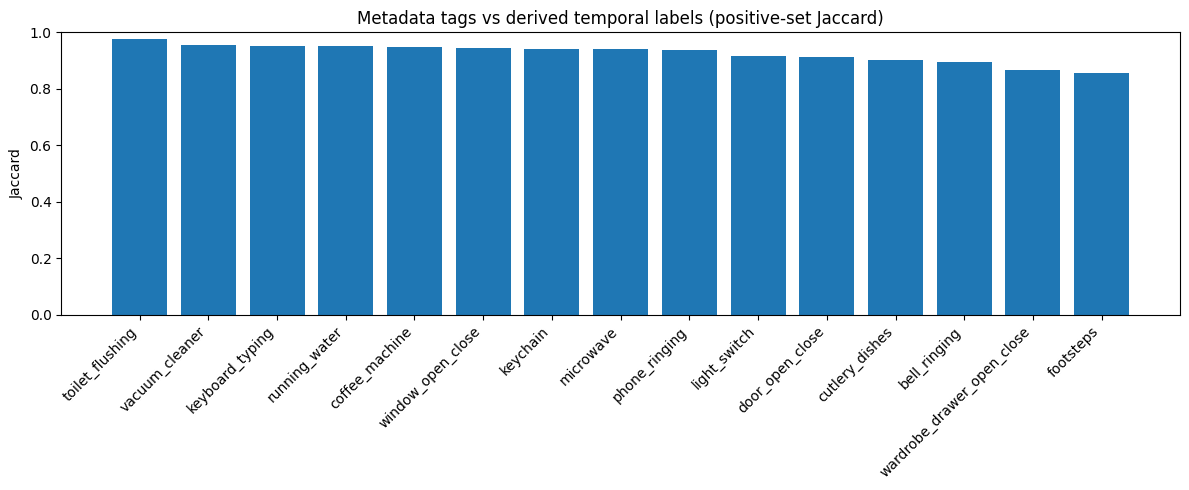

In [20]:
metadata_temporal_df = pd.DataFrame(metadata_vs_temporal_class_records)

exact_match_rate = float(np.mean(metadata_vs_temporal_exact_match)) if len(metadata_vs_temporal_exact_match) > 0 else np.nan
print("Exact file-level set match between uploader tags and derived temporal labels:", round(exact_match_rate, 4))

def safe_div(num, den):
    return num / den if den != 0 else np.nan

rows = []
for c_name, grp in metadata_temporal_df.groupby("class_name"):
    tp = int(((grp["metadata_tag"] == 1) & (grp["temporal_label"] == 1)).sum())
    tn = int(((grp["metadata_tag"] == 0) & (grp["temporal_label"] == 0)).sum())
    fp = int(((grp["metadata_tag"] == 1) & (grp["temporal_label"] == 0)).sum())
    fn = int(((grp["metadata_tag"] == 0) & (grp["temporal_label"] == 1)).sum())

    rows.append({
        "class_name": c_name,
        "match_rate": safe_div(tp + tn, len(grp)),
        "jaccard_positive_sets": safe_div(tp, tp + fp + fn),
        "metadata_positive_files": int(grp["metadata_tag"].sum()),
        "temporal_positive_files": int(grp["temporal_label"].sum()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
    })

metadata_vs_temporal_summary = pd.DataFrame(rows).sort_values("jaccard_positive_sets", ascending=False)
display(metadata_vs_temporal_summary)

plt.figure(figsize=(12, 5))
plt.bar(metadata_vs_temporal_summary["class_name"], metadata_vs_temporal_summary["jaccard_positive_sets"])
plt.title("Metadata tags vs derived temporal labels (positive-set Jaccard)")
plt.ylabel("Jaccard")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Derived time-step labels: frequency, duration, co-occurrence, environment links (required by rubric 2b/2c)

,class_name,positive_segments,files_with_class
4,footsteps,31392,1831
10,running_water,24593,995
5,keyboard_typing,18626,728
2,cutlery_dishes,15673,816
8,microwave,14050,391
9,phone_ringing,13903,786
3,door_open_close,12482,1189
12,vacuum_cleaner,11837,325
6,keychain,11821,681
1,coffee_machine,7388,207


,class_name,num_events,mean_duration_s,median_duration_s,total_duration_s
3,footsteps,2989,5.751255,5.0,17190.5
8,running_water,1070,11.992056,10.0,12831.5
0,keyboard_typing,968,10.120868,8.5,9797.0
7,cutlery_dishes,1503,5.713906,4.0,8588.0
1,phone_ringing,1034,7.222921,5.5,7468.5
10,microwave,523,13.932122,15.0,7286.5
2,door_open_close,1966,3.674466,3.0,7224.0
5,keychain,1092,5.912546,5.0,6456.5
12,vacuum_cleaner,333,18.273273,17.5,6085.0
6,wardrobe_drawer_open_close,1115,3.648430,3.0,4068.0


,class_1,class_2,count
1,door_open_close,footsteps,914
5,footsteps,light_switch,533
4,footsteps,keychain,489
2,door_open_close,keychain,457
3,door_open_close,light_switch,399
29,cutlery_dishes,running_water,383
8,footsteps,running_water,360
0,keyboard_typing,phone_ringing,346
16,footsteps,wardrobe_drawer_open_close,331
21,footsteps,window_open_close,305


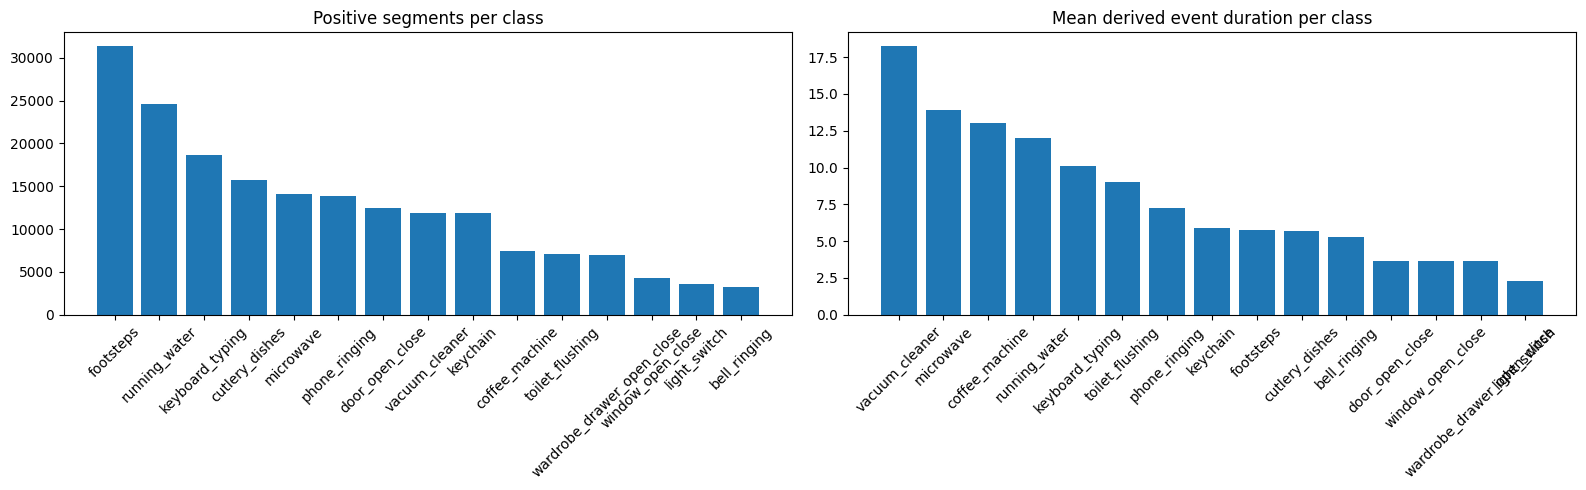

In [21]:
label_frequency_df = pd.DataFrame({
    "class_name": list(positive_segment_counts.keys()),
    "positive_segments": list(positive_segment_counts.values()),
    "files_with_class": [file_presence_counts[c] for c in positive_segment_counts.keys()],
})
if label_frequency_df.empty:
    label_frequency_df = empty_df(["class_name", "positive_segments", "files_with_class"])
else:
    label_frequency_df = label_frequency_df.sort_values("positive_segments", ascending=False)

duration_rows = [
    {
        "class_name": c_name,
        "num_events": len(durs),
        "mean_duration_s": float(np.mean(durs)) if len(durs) > 0 else np.nan,
        "median_duration_s": float(np.median(durs)) if len(durs) > 0 else np.nan,
        "total_duration_s": float(np.sum(durs)) if len(durs) > 0 else np.nan,
    }
    for c_name, durs in segment_event_durations.items()
]
duration_df = pd.DataFrame(duration_rows)
if duration_df.empty:
    duration_df = empty_df(["class_name", "num_events", "mean_duration_s", "median_duration_s", "total_duration_s"])
else:
    duration_df = duration_df.sort_values("total_duration_s", ascending=False)

cooccurrence_rows = [
    {"class_1": c1, "class_2": c2, "count": count}
    for (c1, c2), count in cooccurrence_counts.items()
]
cooccurrence_df = pd.DataFrame(cooccurrence_rows)
if cooccurrence_df.empty:
    cooccurrence_df = empty_df(["class_1", "class_2", "count"])
else:
    cooccurrence_df = cooccurrence_df.sort_values("count", ascending=False)

display(label_frequency_df)
display(duration_df.head(15))
display(cooccurrence_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if not label_frequency_df.empty:
    axes[0].bar(label_frequency_df["class_name"], label_frequency_df["positive_segments"])
    axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Positive segments per class")

if not duration_df.empty:
    top_dur = duration_df.sort_values("mean_duration_s", ascending=False)
    axes[1].bar(top_dur["class_name"], top_dur["mean_duration_s"])
    axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Mean derived event duration per class")

plt.tight_layout()
plt.show()

,environment,class_name,files_in_environment,files_with_class_in_environment,enrichment
210,pantry,microwave,1,1,9.350384
246,kitchen_or_living_room,microwave,1,1,9.350384
257,toilet_hallway,toilet_flushing,1,1,9.027160
134,hall,toilet_flushing,1,1,9.027160
223,restroom,toilet_flushing,1,1,9.027160
139,cafeteria,coffee_machine,2,1,8.830918
156,dining_room,coffee_machine,2,1,8.830918
95,toilet,toilet_flushing,199,175,7.938458
275,work_place,window_open_close,1,1,7.600832
247,kitchen_or_living_room,window_open_close,1,1,7.600832


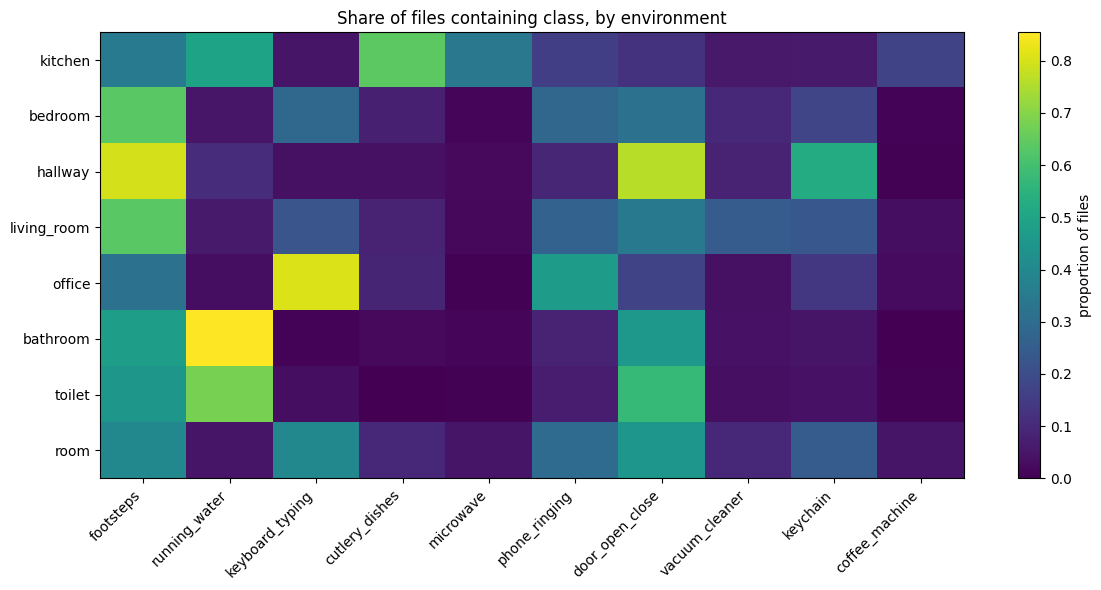

In [22]:
# Environment-class associations based on file-level derived presence
env_class_rows = []
for env, class_counter in environment_class_presence.items():
    total_env_files = environment_counts[env]
    for c_name, cnt in class_counter.items():
        overall_files = file_presence_counts[c_name]
        enrichment = safe_div(cnt / total_env_files, overall_files / max(num_processed, 1))
        env_class_rows.append({
            "environment": env,
            "class_name": c_name,
            "files_in_environment": total_env_files,
            "files_with_class_in_environment": cnt,
            "enrichment": enrichment,
        })

env_class_df = pd.DataFrame(env_class_rows)
if env_class_df.empty:
    env_class_df = empty_df(["environment", "class_name", "files_in_environment", "files_with_class_in_environment", "enrichment"])
else:
    env_class_df = env_class_df.sort_values("enrichment", ascending=False)
display(env_class_df.head(20))

top_envs = [env for env, _ in environment_counts.most_common(8)]
top_classes = label_frequency_df["class_name"].head(10).tolist()

if len(top_envs) > 0 and len(top_classes) > 0:
    heat = pd.DataFrame(index=top_envs, columns=top_classes, data=0.0)
    for env in top_envs:
        total_env_files = max(environment_counts[env], 1)
        for cls in top_classes:
            heat.loc[env, cls] = environment_class_presence[env][cls] / total_env_files

    plt.figure(figsize=(12, 6))
    plt.imshow(heat.values.astype(float), aspect="auto")
    plt.xticks(range(len(top_classes)), top_classes, rotation=45, ha="right")
    plt.yticks(range(len(top_envs)), top_envs)
    plt.title("Share of files containing class, by environment")
    plt.colorbar(label="proportion of files")
    plt.tight_layout()
    plt.show()
else:
    print("No environment/class association data available to plot.")

## 9. Basic feature statistics (required by rubric 3b)

In [23]:
feature_stats_rows = []
for key, stat in feature_stats.items():
    if stat["count"] == 0:
        continue
    mean = stat["sum"] / stat["count"]
    var = max(stat["sumsq"] / stat["count"] - mean ** 2, 0.0)
    std = np.sqrt(var)
    feature_stats_rows.append({
        "feature_key": key,
        "base_feature": key.rsplit("_", 1)[0],
        "aggregation": key.rsplit("_", 1)[1],
        "count": int(stat["count"]),
        "mean": mean,
        "std": std,
        "min": stat["min"],
        "max": stat["max"],
        "range": stat["max"] - stat["min"],
    })

feature_stats_df = pd.DataFrame(feature_stats_rows)
if feature_stats_df.empty:
    feature_stats_df = empty_df(["feature_key", "base_feature", "aggregation", "count", "mean", "std", "min", "max", "range"])
    family_summary_df = empty_df(["mean", "std", "range"])
else:
    feature_stats_df = feature_stats_df.sort_values(["base_feature", "aggregation"])
    family_summary_df = (
        feature_stats_df.groupby("base_feature")[["mean", "std", "range"]]
        .mean()
        .sort_values("range", ascending=False)
    )

display(feature_stats_df)
display(family_summary_df)

,feature_key,base_feature,aggregation,count,mean,std,min,max,range
35,bandwidth_max,bandwidth,max,168239,3404.293156,501.853230,0.000000e+00,4951.661621,4951.661621
32,bandwidth_mean,bandwidth,mean,168239,2784.847200,518.917377,0.000000e+00,4359.974609,4359.974609
34,bandwidth_min,bandwidth,min,168239,2119.948955,642.865164,0.000000e+00,3944.794189,3944.794189
33,bandwidth_std,bandwidth,std,168239,289.658313,175.762964,0.000000e+00,1872.753052,1872.753052
31,centroid_max,centroid,max,168239,3355.276313,1072.791158,0.000000e+00,7615.977539,7615.977539
28,centroid_mean,centroid,mean,168239,2207.009413,884.198620,0.000000e+00,5788.951660,5788.951660
30,centroid_min,centroid,min,168239,1354.665400,828.640773,0.000000e+00,5129.380371,5129.380371
29,centroid_std,centroid,std,168239,450.254301,259.639838,0.000000e+00,2641.416260,2641.416260
39,contrast_max,contrast,max,1177673,27.052031,11.538934,3.358704e+00,80.107056,76.748352
36,contrast_mean,contrast,mean,1177673,15.740927,11.198498,2.513062e+00,67.321274,64.808212


,mean,std,range
base_feature,,,
power,179.039827,530.789476,24860.711914
rolloff_high,3900.309439,1150.903743,6595.413086
centroid,1841.801357,761.317597,5293.931458
rolloff_low,353.111197,367.282083,4108.787109
bandwidth,2149.686906,459.849684,3782.295868
energy,44.904031,64.861201,906.447739
mfcc,-1.229553,10.824912,132.586090
flux,3.194802,4.453324,70.513011
contrast,13.825501,8.507613,54.320823


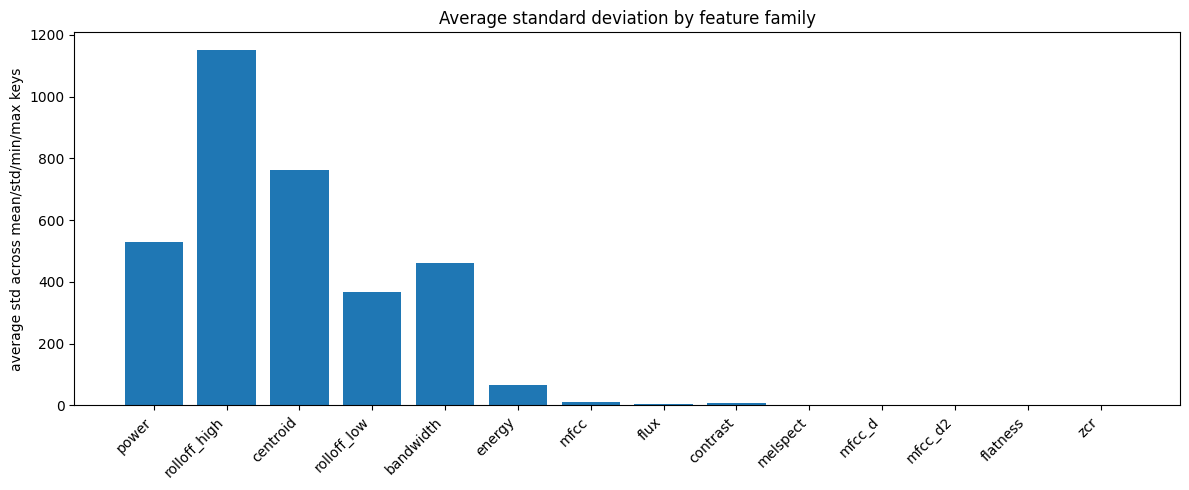

In [24]:
if family_summary_df.empty:
    print("No feature statistics available to plot.")
else:
    plt.figure(figsize=(12, 5))
    plt.bar(family_summary_df.index, family_summary_df["std"])
    plt.title("Average standard deviation by feature family")
    plt.ylabel("average std across mean/std/min/max keys")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 10. Feature-family correlations (required by rubric 3c)

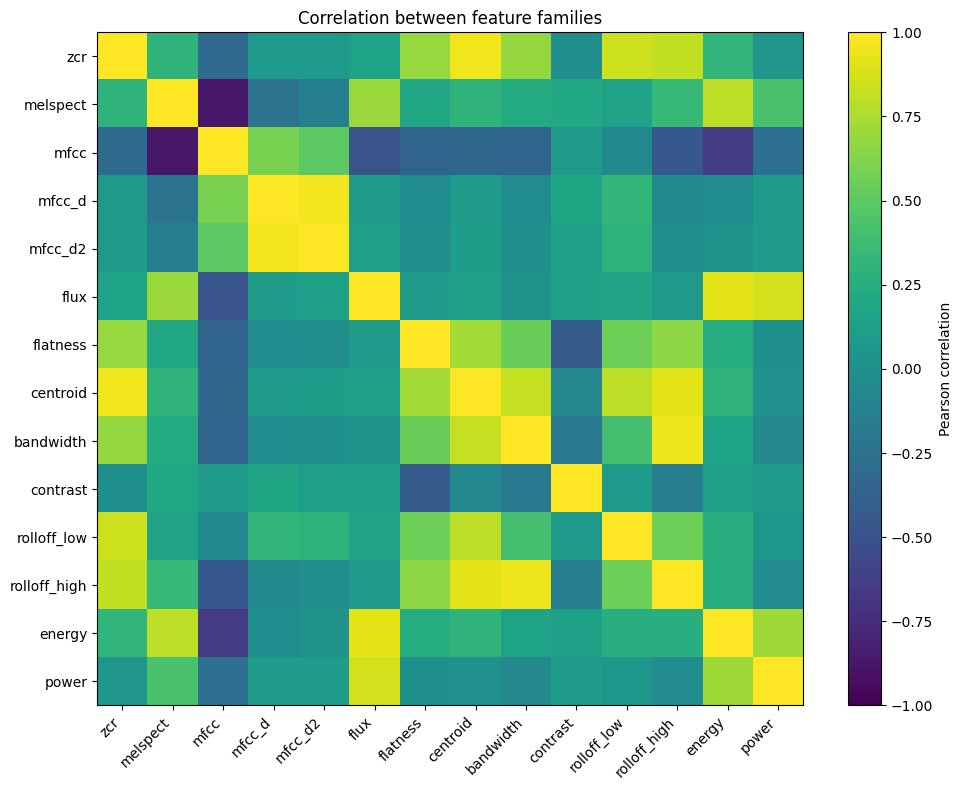

,feature_1,feature_2,correlation,abs_correlation
36,mfcc_d,mfcc_d2,0.962802,0.962802
6,zcr,centroid,0.959812,0.959812
78,bandwidth,rolloff_high,0.951628,0.951628
61,flux,energy,0.918671,0.918671
73,centroid,rolloff_high,0.918228,0.918228
13,melspect,mfcc,-0.867691,0.867691
62,flux,power,0.865605,0.865605
9,zcr,rolloff_low,0.845347,0.845347
70,centroid,bandwidth,0.826458,0.826458
10,zcr,rolloff_high,0.814721,0.814721


In [25]:
feature_family_df = pd.DataFrame(feature_family_rows)

if feature_family_df.empty:
    family_corr = pd.DataFrame()
    top_corr_pairs_df = empty_df(["feature_1", "feature_2", "correlation", "abs_correlation"])
    print("No feature-family rows available for correlation analysis.")
else:
    family_corr = feature_family_df[FEATURE_BASES].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(family_corr.values, aspect="auto", vmin=-1, vmax=1)
    plt.xticks(range(len(FEATURE_BASES)), FEATURE_BASES, rotation=45, ha="right")
    plt.yticks(range(len(FEATURE_BASES)), FEATURE_BASES)
    plt.title("Correlation between feature families")
    plt.colorbar(label="Pearson correlation")
    plt.tight_layout()
    plt.show()

    pairs = []
    for i, f1 in enumerate(FEATURE_BASES):
        for j, f2 in enumerate(FEATURE_BASES):
            if j <= i:
                continue
            pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "correlation": family_corr.loc[f1, f2],
                "abs_correlation": abs(family_corr.loc[f1, f2]),
            })

    top_corr_pairs_df = pd.DataFrame(pairs).sort_values("abs_correlation", ascending=False)

display(top_corr_pairs_df.head(20))

## 11. Down-projection / feature space visualization (bonus task 3d)

This section follows the task hint:
- use a **high-quality subset**
- focus on **segments**, not whole files
- prefer **single-class segments**
- use a **2D down-projection**

In [26]:
print("Segments collected for PCA:", len(viz_features))
print("Class counts in PCA subset:")
viz_counts_series = pd.Series(viz_counts_per_class, dtype=int).sort_values(ascending=False)
display(viz_counts_series.to_frame("count"))

Segments collected for PCA: 3750
Class counts in PCA subset:


,count
keyboard_typing,250
door_open_close,250
footsteps,250
light_switch,250
keychain,250
wardrobe_drawer_open_close,250
cutlery_dishes,250
running_water,250
toilet_flushing,250
phone_ringing,250


In [27]:
X_viz = np.asarray(viz_features, dtype=np.float32)
y_viz = np.asarray(viz_labels)
env_viz = np.asarray(viz_environments)
support_viz = np.asarray(viz_supports)

HAS_PCA_DATA = len(X_viz) > 0

if not HAS_PCA_DATA:
    print("No visualization segments collected. Try lowering HIGH_AGREEMENT_THRESHOLD.")
else:
    scaler = StandardScaler()
    X_viz_scaled = scaler.fit_transform(X_viz)

    pca_2d = PCA(n_components=2, random_state=42)
    X_viz_pca = pca_2d.fit_transform(X_viz_scaled)

    print("PCA explained variance ratio (PC1 + PC2):", round(float(pca_2d.explained_variance_ratio_.sum()), 4))

PCA explained variance ratio (PC1 + PC2): 0.4769


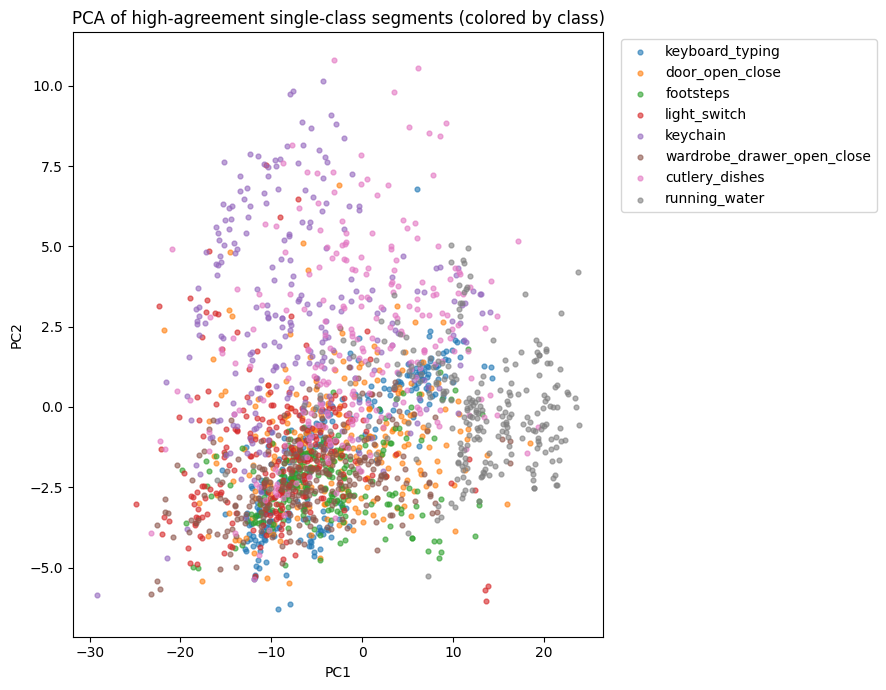

In [28]:
if not HAS_PCA_DATA:
    print("Skipping class-colored PCA plot because no PCA subset was collected.")
else:
    class_counts_for_plot = pd.Series(y_viz).value_counts()
    top_classes_for_plot = class_counts_for_plot.head(8).index.tolist()
    mask = np.isin(y_viz, top_classes_for_plot)

    plt.figure(figsize=(9, 7))
    for cls in top_classes_for_plot:
        cls_mask = (y_viz == cls) & mask
        plt.scatter(
            X_viz_pca[cls_mask, 0],
            X_viz_pca[cls_mask, 1],
            s=12,
            alpha=0.6,
            label=cls
        )

    plt.title("PCA of high-agreement single-class segments (colored by class)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

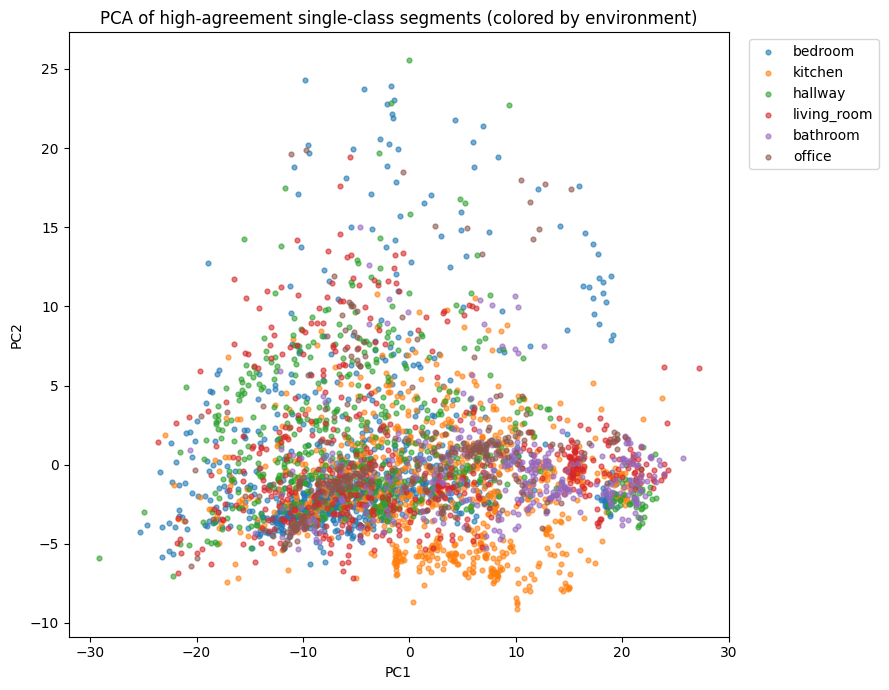

In [29]:
if not HAS_PCA_DATA:
    print("Skipping environment-colored PCA plot because no PCA subset was collected.")
else:
    env_counts_for_plot = pd.Series(env_viz).value_counts()
    top_envs_for_plot = env_counts_for_plot.head(6).index.tolist()
    mask_env = np.isin(env_viz, top_envs_for_plot)

    plt.figure(figsize=(9, 7))
    for env in top_envs_for_plot:
        env_mask = (env_viz == env) & mask_env
        plt.scatter(
            X_viz_pca[env_mask, 0],
            X_viz_pca[env_mask, 1],
            s=12,
            alpha=0.6,
            label=env
        )

    plt.title("PCA of high-agreement single-class segments (colored by environment)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 12. Text snippets you can reuse in the report

### For rubric 2(a): Annotator agreement
- We quantified agreement on the **segment level** using the time-aligned annotation array `annotations[T, C, A]` provided in the `.npz` files.
- For each annotator, class, and segment, we binarized the overlap value using the rule **overlap > 0**.
- We then computed **pairwise Jaccard agreement** between annotators for each class and averaged these scores across files.

### For rubric 2(b): Convert annotations to labels
- We derived binary class labels for every segment by first binarizing per-annotator overlap values and then aggregating them across annotators.
- The final label for a segment and class was set to 1 if at least **50% of annotators** marked that segment as positive.
- This method assumes equal annotator reliability and treats any overlap as evidence that the class is present in the corresponding 1-second segment.

### For rubric 2(c): Label characteristics
- We analyzed class frequencies, file-level presence, approximate event durations from contiguous positive segment runs, class co-occurrence patterns, and class-environment associations.

### For rubric 3(a): Metadata
- We analyzed the distribution of device placement, recording environments, and recording devices.

### For rubric 3(b): Feature statistics
- We computed mean, standard deviation, minimum, maximum, and range for each provided acoustic feature key over the full development set.

### For rubric 3(c): Feature correlation
- We summarized each feature family at the file level and computed a correlation matrix across feature families to identify strongly related acoustic descriptors.

### For rubric 3(d): Down-projection
- We selected a high-quality subset of **single-class, high-agreement segments** and projected the resulting feature vectors into two dimensions using **PCA**.
- We visualized the PCA space by coloring points according to class labels and recording environments to inspect whether meaningful structure is visible.

## 13. Checklist before submission

- Verify that your team also completed the **Label Studio review task** and collected screenshots/notes for the qualitative part.
- Keep the **segment-level annotation analysis** in the report.
- Keep the **aggregation assumptions** and **possible failure cases** in the report.
- Keep the **PCA down-projection** as the bonus visualization, not KMeans.
- Add the mandatory **Disclosure of LLM and AI Tool Use** section at the end of the report.